1. Install Dependencies in Notebook Runtime

In [33]:
# Uncomment in a fresh Colab or notebook runtime.
# %pip install -q "numpy<2" unsloth trl datasets bitsandbytes transformers torch httpx matplotlib python-dotenv openenv jupytext nbformat

import sys
import subprocess

print('Install the required packages above before running the remaining cells.')

Install the required packages above before running the remaining cells.


2. Set Configuration and Runtime Paths

In [34]:
import json
import os
from urllib.request import Request, urlopen

import torch


def _env(name: str, default=None, cast=str):
    raw = os.getenv(name)
    if raw is None or raw == "":
        return default
    try:
        return cast(raw)
    except Exception:
        return default


ENV_URL = _env("OFFICEAGENT_ENV_URL", "http://localhost:7860", str)
BENCHMARK = _env("OFFICEAGENT_BENCHMARK", "officeagentenv", str)
MAX_EPISODES = _env("OFFICEAGENT_MAX_EPISODES", 3, int)
STEPS_PER_EPISODE = _env("OFFICEAGENT_STEPS_PER_EPISODE", 15, int)
RANDOMIZE_EPISODE_SEEDS = _env("OFFICEAGENT_RANDOMIZE_SEEDS", True, lambda x: str(x).lower() in {"1", "true", "yes"})
BASE_SEED = _env("OFFICEAGENT_BASE_SEED", 42, int)
EXPLORATION_EPSILON = _env("OFFICEAGENT_EXPLORATION_EPSILON", 0.20, float)

SMOKE_TEST_MODEL_NAME = _env("OFFICEAGENT_SMOKE_MODEL", "sshleifer/tiny-gpt2", str)
BASE_MODEL_NAME = _env("OFFICEAGENT_BASE_MODEL", "Qwen/Qwen2.5-7B-Instruct", str)
if not torch.cuda.is_available() and os.getenv("OFFICEAGENT_BASE_MODEL") is None:
    BASE_MODEL_NAME = SMOKE_TEST_MODEL_NAME

OUTPUT_DIR = _env("OFFICEAGENT_OUTPUT_DIR", "/content/officeagent-ft", str)

BATCH_SIZE = _env("OFFICEAGENT_BATCH_SIZE", 2 if torch.cuda.is_available() else 1, int)
EPOCHS = _env("OFFICEAGENT_EPOCHS", 2 if torch.cuda.is_available() else 1, int)
LEARNING_RATE = _env("OFFICEAGENT_LEARNING_RATE", 2e-4, float)
MAX_SEQ_LENGTH = _env("OFFICEAGENT_MAX_SEQ_LENGTH", 2048 if torch.cuda.is_available() else 256, int)

# Optional classifier rules through env var, e.g.
# OFFICEAGENT_CLASSIFIER_RULES_JSON='{"spam":["free","offer"],"urgent_task":["urgent"],"meeting_request":["meeting"]}'
CLASSIFIER_RULES = _env("OFFICEAGENT_CLASSIFIER_RULES_JSON", {}, json.loads)
if not isinstance(CLASSIFIER_RULES, dict):
    CLASSIFIER_RULES = {}

# Discover task list dynamically from running environment.
TASK_CANDIDATES = ["easy", "medium", "hard"]
try:
    req = Request(f"{ENV_URL}/tasks", headers={"Accept": "application/json"})
    with urlopen(req, timeout=5) as response:
        payload = json.loads(response.read().decode("utf-8"))
    task_names = [item.get("name") for item in payload.get("tasks", []) if isinstance(item, dict)]
    if task_names:
        TASK_CANDIDATES = task_names
except Exception:
    pass

TASK = _env("OFFICEAGENT_TASK", TASK_CANDIDATES[0], str)
if TASK not in TASK_CANDIDATES:
    TASK = TASK_CANDIDATES[0]

CATEGORY_LABELS = _env(
    "OFFICEAGENT_CATEGORY_LABELS",
    ["meeting_request", "urgent_task", "spam", "general_query"],
    lambda x: [part.strip() for part in str(x).split(",") if part.strip()],
)

print({
    "ENV_URL": ENV_URL,
    "BENCHMARK": BENCHMARK,
    "TASK": TASK,
    "TASK_CANDIDATES": TASK_CANDIDATES,
    "MAX_EPISODES": MAX_EPISODES,
    "STEPS_PER_EPISODE": STEPS_PER_EPISODE,
    "RANDOMIZE_EPISODE_SEEDS": RANDOMIZE_EPISODE_SEEDS,
    "EXPLORATION_EPSILON": EXPLORATION_EPSILON,
    "BASE_MODEL_NAME": BASE_MODEL_NAME,
    "OUTPUT_DIR": OUTPUT_DIR,
    "CATEGORY_LABELS": CATEGORY_LABELS,
    "CLASSIFIER_RULES_KEYS": list(CLASSIFIER_RULES.keys()),
})

{'ENV_URL': 'http://localhost:7860', 'BENCHMARK': 'officeagentenv', 'TASK': 'easy', 'TASK_CANDIDATES': ['easy', 'medium', 'hard'], 'MAX_EPISODES': 3, 'STEPS_PER_EPISODE': 15, 'RANDOMIZE_EPISODE_SEEDS': True, 'EXPLORATION_EPSILON': 0.2, 'BASE_MODEL_NAME': 'sshleifer/tiny-gpt2', 'OUTPUT_DIR': '/content/officeagent-ft', 'CATEGORY_LABELS': ['meeting_request', 'urgent_task', 'spam', 'general_query'], 'CLASSIFIER_RULES_KEYS': []}


3. Import Libraries and Validate GPU


In [35]:
import os
import random
import time
from typing import Any, Dict, List

import httpx
import matplotlib.pyplot as plt
import torch
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

print(f"torch: {torch.__version__}")
print(f"cuda_available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"cuda_device: {torch.cuda.get_device_name(0)}")
    print(f"cuda_capability: {torch.cuda.get_device_capability(0)}")
    print(f"default_dtype: {torch.float16}")
else:
    print("Running on CPU; training will be slow.")

torch: 2.11.0+cpu
cuda_available: False
Running on CPU; training will be slow.


4. Define Environment API Helpers (reset, step)


In [36]:
def env_reset(seed: int = 42) -> Dict[str, Any]:
    try:
        response = httpx.post(
            f"{ENV_URL}/reset",
            json={"task": TASK, "seed": seed},
            timeout=30,
        )
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, dict):
            raise ValueError("reset payload must be a dict")
        # /reset returns {'observation': ..., 'reward': 0, ...}; return the inner observation.
        observation = payload.get("observation", payload)
        if not isinstance(observation, dict):
            raise ValueError("reset observation must be a dict")
        return observation
    except Exception as exc:
        print(f"[ERROR] Reset failed: {exc}")
        return {}


def env_step(action: Dict[str, Any]) -> Dict[str, Any]:
    try:
        response = httpx.post(f"{ENV_URL}/step", json=action, timeout=30)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, dict):
            raise ValueError("step payload must be a dict")
        # Keep step payload intact (contains reward/done/observation/info).
        return payload
    except Exception as exc:
        print(f"[ERROR] Step failed: {exc}")
        return {"done": True, "reward": -1.0, "error": str(exc), "observation": {}}

print("Environment helpers ready.")

Environment helpers ready.


5. Format Observation/Action Text and Heuristic Policy


In [37]:

def format_observation_as_text(obs: Dict[str, Any]) -> str:
    text_parts: List[str] = []
    if obs.get("pending_emails"):
        text_parts.append("PENDING EMAILS:")
        for idx, email in enumerate(obs["pending_emails"][:5], start=1):
            text_parts.append(
                f"  {idx}. From: {email.get('sender', '')}, Subject: {email.get('subject', '')}"
            )
    if obs.get("calendar_events"):
        text_parts.append("\nCALENDAR EVENTS:")
        for event in obs["calendar_events"][:3]:
            text_parts.append(f"  - {event.get('title', '')} at {event.get('start_time', '')}")
    if "current_step" in obs:
        text_parts.append(f"\nCurrent Step: {obs['current_step']}")
    return "\n".join(text_parts)


def format_action_as_text(action: Dict[str, Any]) -> str:
    action_type = action.get("action_type", "unknown")
    email_id = action.get("email_id", "")
    if action_type == "classify_email":
        return f"CLASSIFY email {email_id} as {action.get('category', '')}"
    if action_type == "reply_email":
        return f"REPLY to email {email_id}: {action.get('reply_text', '')[:100]}..."
    if action_type == "schedule_meeting":
        return f"SCHEDULE meeting '{action.get('meeting_title', '')}' at {action.get('meeting_start_time', '')}"
    if action_type == "ignore_email":
        return f"IGNORE email {email_id}"
    return f"ACTION: {action_type}"


def _classify_from_rules(email: Dict[str, Any], rules: Dict[str, List[str]]) -> str:
    text = f"{email.get('subject', '')} {email.get('body', '')}".lower()
    for label, terms in rules.items():
        if not isinstance(terms, list):
            continue
        for term in terms:
            term_text = str(term).strip().lower()
            if term_text and term_text in text:
                return str(label)
    return ""


def heuristic_action(obs: Dict[str, Any]) -> Dict[str, Any]:
    pending = obs.get("pending_emails", [])
    if not pending:
        return {"action_type": "ignore_email", "email_id": "none"}

    email = pending[0]
    email_id = email.get("email_id") or email.get("id") or "0"

    categories = CATEGORY_LABELS if isinstance(CATEGORY_LABELS, list) and CATEGORY_LABELS else ["general_query"]
    rule_based = _classify_from_rules(email, CLASSIFIER_RULES)
    if rule_based in categories:
        base_category = rule_based
    else:
        # No hardcoded keyword map: deterministic fallback from email text.
        text = f"{email.get('subject', '')} {email.get('body', '')}".strip().lower()
        base_category = categories[hash(text) % len(categories)] if text else categories[0]

    # Add light exploration so collected trajectories are more diverse.
    if random.random() < EXPLORATION_EPSILON:
        category = random.choice(categories)
    else:
        category = base_category

    return {
        "action_type": "classify_email",
        "email_id": email_id,
        "category": category,
    }

print("Formatting helpers and heuristic policy ready.")

Formatting helpers and heuristic policy ready.


6. Collect Trajectories from OfficeAgentEnv


In [38]:
trajectories: List[Dict[str, Any]] = []
reward_history: List[float] = []

print("[STEP 1] Collecting trajectories...")
for episode_idx in range(1, MAX_EPISODES + 1):
    episode_seed = (int(time.time()) + episode_idx) if RANDOMIZE_EPISODE_SEEDS else (BASE_SEED + episode_idx)
    obs = env_reset(seed=episode_seed)
    if not obs:
        continue

    trajectory = {"episode": episode_idx, "seed": episode_seed, "steps": [], "total_reward": 0.0}
    cumulative_reward = 0.0

    for step_idx in range(STEPS_PER_EPISODE):
        obs_text = format_observation_as_text(obs)
        action = heuristic_action(obs)
        action_text = format_action_as_text(action)

        step_result = env_step(action)
        reward = float(step_result.get("reward", -1.0))
        done = bool(step_result.get("done", False))
        cumulative_reward += reward

        trajectory["steps"].append(
            {
                "observation": obs_text,
                "action": action_text,
                "action_dict": action,
                "reward": reward,
                "done": done,
            }
        )

        print(f"  Episode {episode_idx}, Step {step_idx + 1}: reward={reward:.2f}")
        if done:
            break
        obs = step_result.get("observation", obs)

    trajectory["total_reward"] = cumulative_reward
    trajectories.append(trajectory)
    reward_history.append(cumulative_reward)
    time.sleep(0.3)

avg_reward = sum(reward_history) / len(reward_history) if reward_history else 0.0
print(f"[SUMMARY] Episodes: {len(trajectories)}, Avg Reward: {avg_reward:.4f}")
print(f"[SEEDS] {[traj.get('seed') for traj in trajectories]}")

[STEP 1] Collecting trajectories...
  Episode 1, Step 1: reward=0.28
  Episode 1, Step 2: reward=0.28
  Episode 1, Step 3: reward=-0.22
  Episode 1, Step 4: reward=-0.22
  Episode 1, Step 5: reward=0.48
  Episode 2, Step 1: reward=0.28
  Episode 2, Step 2: reward=0.28
  Episode 2, Step 3: reward=-0.22
  Episode 2, Step 4: reward=-0.22
  Episode 2, Step 5: reward=0.48
  Episode 3, Step 1: reward=0.28
  Episode 3, Step 2: reward=0.28
  Episode 3, Step 3: reward=-0.22
  Episode 3, Step 4: reward=-0.22
  Episode 3, Step 5: reward=-0.02
[SUMMARY] Episodes: 3, Avg Reward: 0.4333
[SEEDS] [1776874310, 1776874325, 1776874341]


7. Build SFT Training Dataset


In [39]:
training_examples: List[Dict[str, str]] = []

print("[STEP 2] Preparing training dataset...")
for trajectory in trajectories:
    for step in trajectory["steps"]:
        prompt = f"""You are an executive assistant AI processing emails and scheduling meetings.

{step['observation']}

What action do you take?"""
        completion = step["action"]
        training_examples.append({"text": f"{prompt}\n{completion}"})

train_dataset = Dataset.from_dict({"text": [item["text"] for item in training_examples]})
print(f"[DATA] Created {len(training_examples)} training examples")
if len(train_dataset) > 0:
    print("Sample row:")
    print(train_dataset[0]["text"][:1000])

[STEP 2] Preparing training dataset...
[DATA] Created 15 training examples
Sample row:
You are an executive assistant AI processing emails and scheduling meetings.

PENDING EMAILS:
  1. From: alice@corp.com, Subject: Request: 30-minute roadmap alignment this Thursday
  2. From: bob@spam.net, Subject: Congratulations! Claim your $1000 gift card now
  3. From: ceo@corp.com, Subject: URGENT: Production API outage impacting customers
  4. From: diana@partner.org, Subject: Question: OAuth 2.0 support in partner API
  5. From: hr@corp.com, Subject: Schedule update: Engineering standup moved to 10:00 AM

CALENDAR EVENTS:
  - Weekly Sync at 2024-07-01 10:00
  - Lunch Break at 2024-07-01 12:00

Current Step: 0

What action do you take?
CLASSIFY email e001 as meeting_request


8. Load Tokenizer/Model and Configure TRL Training


In [40]:
print("[STEP 3] Loading tokenizer and model...")

from trl import SFTConfig, SFTTrainer

# Guard against stale execution order: rebuild train_dataset if it is missing/empty.
if "train_dataset" not in globals() or len(train_dataset) == 0:
    if "trajectories" not in globals() or len(trajectories) == 0:
        raise RuntimeError(
            "No trajectory data available. Run Cell 6 first, then Cell 7, and retry Cell 8."
        )

    training_examples = []
    for trajectory in trajectories:
        for step in trajectory["steps"]:
            prompt = f"""You are an executive assistant AI processing emails and scheduling meetings.

{step['observation']}

What action do you take?"""
            completion = step["action"]
            training_examples.append({"text": f"{prompt}\n{completion}"})

    train_dataset = Dataset.from_dict({"text": [item["text"] for item in training_examples]})

if len(train_dataset) == 0:
    raise RuntimeError(
        "train_dataset is empty. Ensure the environment server is running, then rerun Cells 6 and 7."
    )

print(f"[DATA] Training rows available: {len(train_dataset)}")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
)

optimizer_name = "paged_adamw_32bit" if torch.cuda.is_available() else "adamw_torch"

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    warmup_steps=10 if len(train_dataset) < 100 else 50,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    fp16=torch.cuda.is_available(),
    bf16=False,
    use_cpu=not torch.cuda.is_available(),
    logging_steps=10,
    optim=optimizer_name,
    save_strategy="epoch",
    max_length=MAX_SEQ_LENGTH,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=training_args,
    processing_class=tokenizer,
)

print("Trainer configured.")

[STEP 3] Loading tokenizer and model...
[DATA] Training rows available: 15


Truncating train dataset: 100%|██████████| 15/15 [00:00<00:00, 1612.33 examples/s]


Trainer configured.


9. Run Fine-Tuning and Save Checkpoints


In [41]:
print("[STEP 4] Fine-tuning model...")
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"[SUCCESS] Model saved to {OUTPUT_DIR}")
print(train_result)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


[STEP 4] Fine-tuning model...


Step,Training Loss


[SUCCESS] Model saved to /content/officeagent-ft
TrainOutput(global_step=8, training_loss=10.758427619934082, metrics={'train_runtime': 2.1975, 'train_samples_per_second': 6.826, 'train_steps_per_second': 3.64, 'total_flos': 2190624.0, 'train_loss': 10.758427619934082, 'entropy': 10.824578921000162, 'num_tokens': 2402.0, 'mean_token_accuracy': 0.0, 'epoch': 1.0})


10. Plot Reward Curve and Save Figure


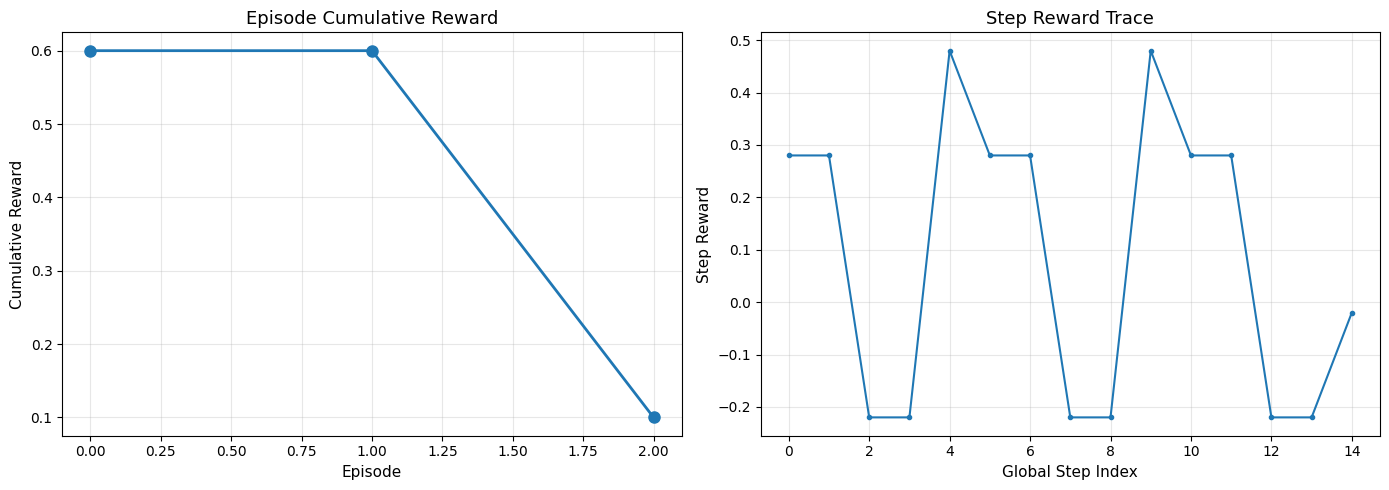

Reward curve saved to /content/reward_curve.png
Episode rewards: [0.6000000000000001, 0.6000000000000001, 0.10000000000000007]
First 20 step rewards: [0.28, 0.28, -0.22, -0.22, 0.48, 0.28, 0.28, -0.22, -0.22, 0.48, 0.28, 0.28, -0.22, -0.22, -0.02]


In [42]:
# Plot episode-level and step-level reward trends.
per_step_rewards = [step["reward"] for traj in trajectories for step in traj["steps"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(reward_history, marker="o", linewidth=2, markersize=8)
axes[0].set_title("Episode Cumulative Reward", fontsize=13)
axes[0].set_xlabel("Episode", fontsize=11)
axes[0].set_ylabel("Cumulative Reward", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(per_step_rewards, marker=".", linewidth=1.5)
axes[1].set_title("Step Reward Trace", fontsize=13)
axes[1].set_xlabel("Global Step Index", fontsize=11)
axes[1].set_ylabel("Step Reward", fontsize=11)
axes[1].grid(True, alpha=0.3)

# Show a note when episode totals are identical so this does not look like a bug.
if reward_history and len(set(round(x, 6) for x in reward_history)) == 1:
    print(
        "[INFO] Episode cumulative rewards are identical in this run; "
        "use the step reward trace to inspect behavior changes."
    )

plt.tight_layout()
reward_plot_path = "/content/reward_curve.png"
plt.savefig(reward_plot_path, dpi=100)
plt.show()

print(f"Reward curve saved to {reward_plot_path}")
print(f"Episode rewards: {reward_history}")
print(f"First 20 step rewards: {per_step_rewards[:20]}")

11. Run Inference Smoke Test on a Sample Observation


In [43]:
sample_observation = {
    "pending_emails": [
        {
            "id": "email_1",
            "sender": "alice@example.com",
            "subject": "Q2 Planning Meeting",
            "body": "Can we schedule a meeting for next week?",
        }
    ],
    "calendar_events": [],
    "current_step": 1,
}

smoke_prompt = f"""You are an executive assistant AI.

{format_observation_as_text(sample_observation)}

What action do you take?"""

inputs = tokenizer(smoke_prompt, return_tensors="pt")
if torch.cuda.is_available():
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=96,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

smoke_output = tokenizer.decode(generated[0], skip_special_tokens=True)
print(smoke_output)

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
c:\Users\sriab\OneDrive\Desktop\Projects\OfficeAgentEnv\.venv\Lib\site-packages\torch\utils\checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


You are an executive assistant AI.

PENDING EMAILS:
  1. From: alice@example.com, Subject: Q2 Planning Meeting

Current Step: 1

What action do you take? stairs factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors


12. Notebook-Only Workflow


In [44]:
notebook_path = "train_officeagent_colab.ipynb"

print("This project uses the notebook as the primary training artifact.")
print(f"Notebook path: {notebook_path}")
print("No separate .py export is needed for this Colab workflow.")

This project uses the notebook as the primary training artifact.
Notebook path: train_officeagent_colab.ipynb
No separate .py export is needed for this Colab workflow.


13. Save Notebook Artifacts to Drive or Local Workspace


In [45]:
from pathlib import Path

artifact_dir = Path(OUTPUT_DIR)
artifact_dir.mkdir(parents=True, exist_ok=True)

artifacts = {
    "trained_model_dir": str(artifact_dir),
    "reward_plot": reward_plot_path if "reward_plot_path" in globals() else str(artifact_dir / "reward_curve.png"),
    "notebook_file": notebook_path,
}

for name, path in artifacts.items():
    print(f"{name}: {path}")

print("Notebook artifacts are ready for local workspace or mounted Drive sync.")

trained_model_dir: \content\officeagent-ft
reward_plot: /content/reward_curve.png
notebook_file: train_officeagent_colab.ipynb
Notebook artifacts are ready for local workspace or mounted Drive sync.
